In [4]:
import pandas as pd

it = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
print("investor_transactions_cleaned shape:", it.shape)
print(it.dtypes)
print(it.head(3))

ph = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
print("\nportfolio_holdings shape:", ph.shape)
print(ph.head(3))

fm = pd.read_csv("../data/raw/01_fund_master.csv")
print("\nrisk_category unique values:", fm["risk_category"].unique())

investor_transactions_cleaned shape: (32778, 13)
investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
dtype: object
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   
2    Haryana  Faridabad  

In [5]:
sp = pd.read_csv("../data/raw/07_scheme_performance.csv")
print("risk_grade unique:", sp["risk_grade"].unique())

print("\ntransaction_type unique:", it["transaction_type"].unique())

print("\nportfolio_holdings unique amfi_codes:", ph["amfi_code"].nunique())
print("weight_pct per fund sum (check ~100):")
print(ph.groupby("amfi_code")["weight_pct"].sum().describe())

# category check - task says "all equity funds" for HHI
print("\nfund_master category unique:", fm["category"].unique())
print("equity fund count:", (fm["category"]=="Equity").sum())

risk_grade unique: ['Moderate' 'Very High' 'Low' 'High' 'Moderately High']

transaction_type unique: ['Sip' 'Redemption' 'Lumpsum']

portfolio_holdings unique amfi_codes: 34
weight_pct per fund sum (check ~100):
count     34.000000
mean      99.999706
std        0.010294
min       99.980000
25%       99.990000
50%      100.000000
75%      100.007500
max      100.020000
Name: weight_pct, dtype: float64

fund_master category unique: ['Equity' 'Debt']
equity fund count: 34


In [7]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv", parse_dates=["date"])
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

var_rows = []
for code, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    var_95 = r.quantile(0.05)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({"amfi_code": code, "var_95_pct": var_95*100, "cvar_95_pct": cvar_95*100})

var_df = pd.DataFrame(var_rows)
fm = pd.read_csv("../data/raw/01_fund_master.csv")
var_table = fm[["amfi_code","scheme_name"]].merge(var_df, on="amfi_code")
var_table = var_table.sort_values("var_95_pct")

print(var_table.head(10))
print("\nvar_95 range:", var_df["var_95_pct"].min(), "to", var_df["var_95_pct"].max())

    amfi_code                                        scheme_name  var_95_pct  \
3      119599          SBI Small Cap Fund - Direct Plan - Growth   -2.685944   
27     119095             Axis Small Cap Fund - Regular - Growth   -2.618842   
29     101207             ABSL Small Cap Fund - Regular - Growth   -2.602125   
17     118634     Nippon India Small Cap Fund - Regular - Growth   -2.543811   
2      119598         SBI Small Cap Fund - Regular Plan - Growth   -2.450705   
39     149324              DSP Small Cap Fund - Regular - Growth   -2.348307   
32     102886                UTI Mid Cap Fund - Regular - Growth   -1.922028   
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   -1.903354   
12     120505           ICICI Pru Midcap Fund - Regular - Growth   -1.889179   
26     119094                Axis Midcap Fund - Regular - Growth   -1.848028   

    cvar_95_pct  
3     -3.238412  
27    -3.166729  
29    -3.245906  
17    -3.230407  
2     -3.059526  
39    -3.10

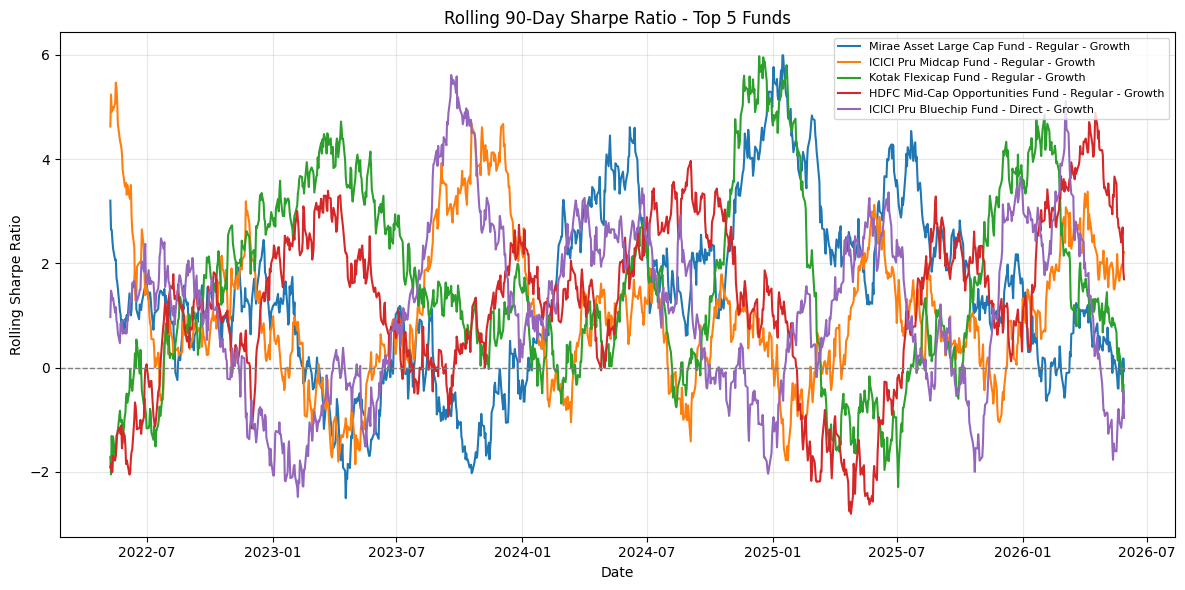

In [11]:
import matplotlib.pyplot as plt

Rf = 0.065
key_funds = [148567, 120505, 120843, 100033, 120504]  # same top5 as scorecard
fund_names = dict(zip(fm["amfi_code"], fm["scheme_name"]))

fig, ax = plt.subplots(figsize=(12,6))
for code in key_funds:
    g = nav[nav["amfi_code"]==code].sort_values("date").copy()
    roll_mean = g["daily_return"].rolling(90).mean()
    roll_std = g["daily_return"].rolling(90).std()
    roll_sharpe = (roll_mean*252 - Rf) / (roll_std*np.sqrt(252))
    ax.plot(g["date"], roll_sharpe, label=fund_names[code])

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Rolling 90-Day Sharpe Ratio - Top 5 Funds")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=150)
plt.show()

In [13]:
it = pd.read_csv("../data/processed/investor_transactions_cleaned.csv", parse_dates=["transaction_date"])

# first transaction year per investor
first_txn = it.groupby("investor_id")["transaction_date"].min().reset_index()
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year
it = it.merge(first_txn[["investor_id","cohort_year"]], on="investor_id")

# avg SIP amount per cohort
sip_only = it[it["transaction_type"]=="Sip"]
avg_sip = sip_only.groupby("cohort_year")["amount_inr"].mean().rename("avg_sip_amount")

# total invested (Sip + Lumpsum, excluding Redemption) per cohort
invest_only = it[it["transaction_type"].isin(["Sip","Lumpsum"])]
total_invested = invest_only.groupby("cohort_year")["amount_inr"].sum().rename("total_invested")

# top fund preference per cohort (most common amfi_code by txn count)
top_fund = invest_only.groupby(["cohort_year","amfi_code"]).size().reset_index(name="txn_count")
top_fund = top_fund.sort_values(["cohort_year","txn_count"], ascending=[True,False]).groupby("cohort_year").first()
top_fund = top_fund.merge(fm[["amfi_code","scheme_name"]], on="amfi_code")[["scheme_name"]].set_index(top_fund.index)

cohort_summary = pd.concat([avg_sip, total_invested], axis=1)
cohort_summary["top_fund"] = top_fund["scheme_name"].values

print(cohort_summary)

             avg_sip_amount  total_invested  \
cohort_year                                   
2024           10996.885825      2258062304   
2025           13505.209581        18992635   

                                                      top_fund  
cohort_year                                                     
2024         HDFC Mid-Cap Opportunities Fund - Direct - Growth  
2025                 SBI Small Cap Fund - Direct Plan - Growth  


In [14]:
sip_txns = it[it["transaction_type"]=="Sip"].sort_values(["investor_id","transaction_date"])

sip_counts = sip_txns.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

continuity_rows = []
for inv_id, g in sip_txns[sip_txns["investor_id"].isin(eligible_investors)].groupby("investor_id"):
    gaps = g["transaction_date"].diff().dt.days.dropna()
    avg_gap = gaps.mean()
    continuity_rows.append({
        "investor_id": inv_id,
        "sip_count": len(g),
        "avg_gap_days": avg_gap,
        "at_risk": avg_gap > 35
    })

continuity_df = pd.DataFrame(continuity_rows)
print("Total eligible investors (6+ SIPs):", len(continuity_df))
print("At-risk count:", continuity_df["at_risk"].sum())
print("At-risk %:", round(continuity_df["at_risk"].mean()*100, 2))
print(continuity_df.head(10))

Total eligible investors (6+ SIPs): 1362
At-risk count: 1332
At-risk %: 97.8
  investor_id  sip_count  avg_gap_days  at_risk
0   INV000004          6     85.400000     True
1   INV000008          6     70.400000     True
2   INV000010          6     64.800000     True
3   INV000011          7     40.166667     True
4   INV000012          8     57.000000     True
5   INV000013          7     55.333333     True
6   INV000014          7     75.333333     True
7   INV000023          8     58.571429     True
8   INV000028          6     93.600000     True
9   INV000029          7     60.666667     True


In [15]:
print(sip_txns.groupby("investor_id")["transaction_date"].count().describe())
print("\nOverall SIP date range:", sip_txns["transaction_date"].min(), "to", sip_txns["transaction_date"].max())
print("Median gap across all eligible investors:", continuity_df["avg_gap_days"].median())

count    4762.000000
mean        4.140277
std         2.315046
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        12.000000
Name: transaction_date, dtype: float64

Overall SIP date range: 2024-01-01 00:00:00 to 2025-05-30 00:00:00
Median gap across all eligible investors: 64.69047619047619


In [17]:
ph = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

hhi_rows = []
for code, g in ph.groupby("amfi_code"):
    hhi = (g["weight_pct"]**2).sum()
    hhi_rows.append({"amfi_code": code, "hhi": hhi})

hhi_df = pd.DataFrame(hhi_rows)
hhi_table = fm[fm["category"]=="Equity"][["amfi_code","scheme_name"]].merge(hhi_df, on="amfi_code")
hhi_table = hhi_table.sort_values("hhi", ascending=False)

print(hhi_table.head(10))
print("\nHHI range:", hhi_df["hhi"].min(), "to", hhi_df["hhi"].max())

    amfi_code                                        scheme_name        hhi
19     119092              Axis Bluechip Fund - Regular - Growth  2064.4767
24     101207             ABSL Small Cap Fund - Regular - Growth  2007.0043
3      119599          SBI Small Cap Fund - Direct Plan - Growth  1747.5096
25     102885         UTI Nifty 50 Index Fund - Regular - Growth  1747.0902
12     118632     Nippon India Large Cap Fund - Regular - Growth  1682.9820
29     148568  Mirae Asset Emerging Bluechip Fund - Regular -...  1679.2973
10     120505           ICICI Pru Midcap Fund - Regular - Growth  1575.7036
11     120506  ICICI Pru Value Discovery Fund - Regular - Growth  1537.9360
7      125498  HDFC Mid-Cap Opportunities Fund - Direct - Growth  1524.1398
16     120841             Kotak Bluechip Fund - Regular - Growth  1496.8035

HHI range: 1073.4895000000001 to 2064.4766999999997


In [18]:
var_table.to_csv("../data/processed/var_cvar_report.csv", index=False)
print("Saved:", var_table.shape)

Saved: (40, 4)


## Advanced Insights

1. **Highest VaR/CVaR risk**: SBI Small Cap Direct Plan has the worst 95% VaR (-2.69%) and 
   CVaR (-3.24%), consistent with small-cap funds dominating the worst-drawdown list — 
   small-cap exposure is the primary risk driver across this fund universe.

2. **Investor cohort behavior**: The 2024 cohort invested significantly more in total 
   (₹225.8 Cr vs ₹1.9 Cr for 2025), naturally reflecting more time in market, but the 
   2025 cohort shows a higher average SIP amount (₹13,505 vs ₹10,997), suggesting newer 
   investors are committing larger amounts per SIP.

3. **SIP continuity is weak**: Of 1,362 investors with 6+ SIP transactions, 97.8% show an 
   average gap exceeding 35 days between SIPs (median gap ~65 days) — indicating most 
   "regular" SIP investors are not maintaining true monthly discipline within this dataset's 
   ~17-month window.

4. **Fund preference by cohort**: HDFC Mid-Cap Opportunities Direct led transaction volume 
   for the 2024 cohort, while SBI Small Cap Direct led for 2025 — suggesting a shift toward 
   small-cap preference among newer investors.

5. **Portfolio concentration**: HHI ranges from ~1073 to ~2064 across equity funds. Axis 
   Bluechip and ABSL Small Cap are the most concentrated (HHI > 2000), meaning a larger 
   share of returns depends on fewer top holdings — worth flagging for risk-conscious investors.